# Bank Marketing — Age Regression Project

**Target:** `age` — client's age

**Features:** `job`, `marital`, `education`, `default`, `balance`, `housing`, `loan`, `contact`, `campaign`, `pdays`, `previous`, `poutcome`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Load data

In [2]:
df = pd.read_csv("Bank_Marketing.csv", sep=";")
df.shape

(45211, 17)

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Quick sanity checks

In [4]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## 3. Exploratory Data Analysis

Let's look at the `age` distribution and how it relates to a couple of categorical features.

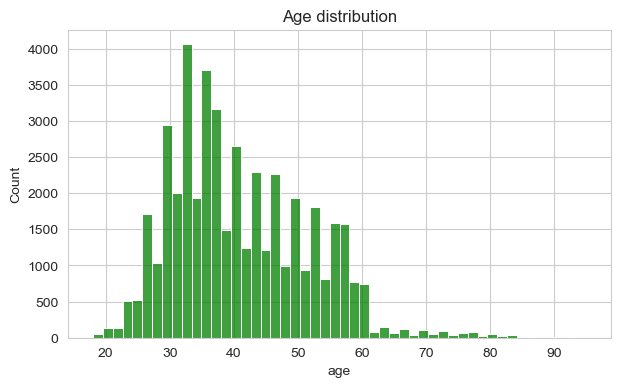

In [5]:
plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=50,color='green')
plt.title("Age distribution")
plt.show()

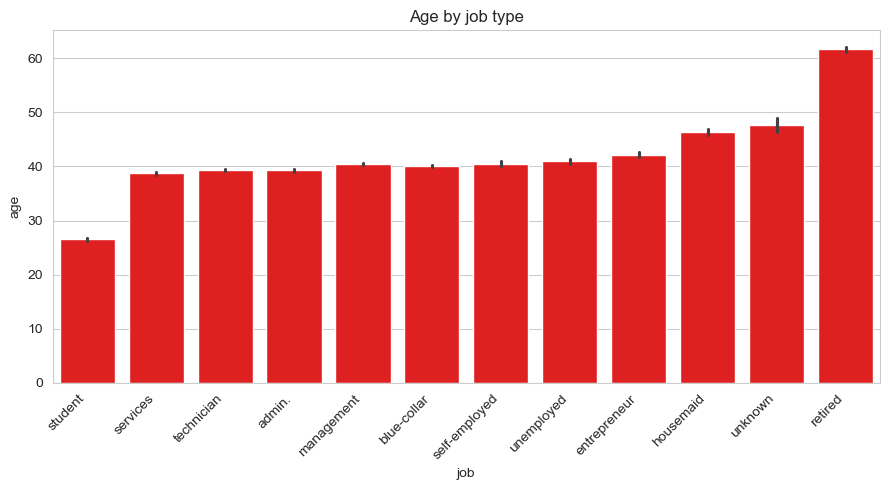

In [6]:
plt.figure(figsize=(9, 5))
order = df.groupby("job")["age"].median().sort_values().index
sns.barplot(x="job", y="age", data=df, order=order,color='red')
plt.xticks(rotation=45, ha="right")
plt.title("Age by job type")
plt.tight_layout()
plt.show()

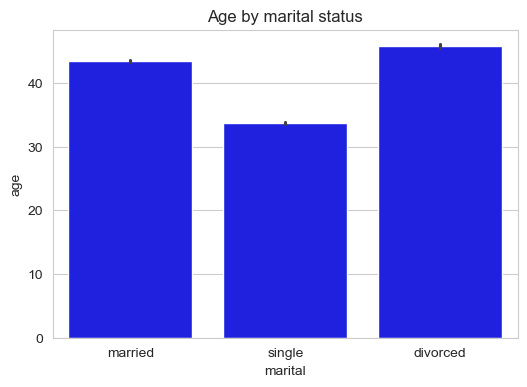

In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(x="marital", y="age", data=df,color='blue')
plt.title("Age by marital status")
plt.show()

## 4. Define features & target

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
FEATURES = ["job", "marital", "education", "default", "balance", "housing",
"loan", "contact", "campaign", "pdays", "previous", "poutcome"]
TARGET = "age"

X = df[FEATURES].copy()
y = df[TARGET].copy()

numeric_features = ["balance", "campaign", "pdays", "previous"]
categorical_features = ["job", "marital", "education", "default",
"housing", "loan", "contact", "poutcome"]

## 5. Train and test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. Preprocessor

In [11]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_features),
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

# 7.Linear Regression

In [12]:
pipe = Pipeline(steps=[("prep", preprocessor),("model", LinearRegression())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mean=df['age'].mean()
print(f"  MAE : {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")
print(f'  Mean of target: {mean}')

  MAE : 6.57
  RMSE: 8.10
  R2  : 0.4180
  Mean of target: 40.93621021432837


### Desicion tree regressor

In [13]:
from sklearn.tree import DecisionTreeRegressor

pipe = Pipeline(steps=[("prep", preprocessor),("model", DecisionTreeRegressor())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mean=df['age'].mean()
print(f"  MAE : {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")
print(f'  Mean of target: {mean}')

  MAE : 8.59
  RMSE: 11.14
  R2  : -0.1002
  Mean of target: 40.93621021432837


## Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline(steps=[("prep", preprocessor),("model", RandomForestRegressor())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mean=df['age'].mean()
print(f"  MAE : {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")
print(f'  Mean of target: {mean}')

  MAE : 6.69
  RMSE: 8.41
  R2  : 0.3727
  Mean of target: 40.93621021432837


# SVR

In [15]:
from sklearn.svm import SVR

pipe = Pipeline(steps=[("prep", preprocessor),("model", SVR())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mean=df['age'].mean()
print(f"  MAE : {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")
print(f'  Mean of target: {mean}')

  MAE : 6.41
  RMSE: 8.11
  R2  : 0.4167
  Mean of target: 40.93621021432837


# Ridge

In [16]:
from sklearn.linear_model import Ridge

pipe = Pipeline(steps=[("prep", preprocessor),("model", Ridge())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mean=df['age'].mean()
print(f"  MAE : {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")
print(f'  Mean of target: {mean}')

  MAE : 6.57
  RMSE: 8.10
  R2  : 0.4181
  Mean of target: 40.93621021432837


# Lasso

In [17]:
from sklearn.linear_model import Lasso

pipe = Pipeline(steps=[("prep", preprocessor),("model", Lasso())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mean=df['age'].mean()
print(f"  MAE : {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")
print(f'  Mean of target: {mean}')

  MAE : 8.01
  RMSE: 9.85
  R2  : 0.1392
  Mean of target: 40.93621021432837


# ElasticNet

In [18]:
from sklearn.linear_model import ElasticNet

pipe = Pipeline(steps=[("prep", preprocessor),("model", ElasticNet())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mean=df['age'].mean()
print(f"  MAE : {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R2  : {r2:.4f}")
print(f'  Mean of target: {mean}')

  MAE : 8.18
  RMSE: 9.97
  R2  : 0.1191
  Mean of target: 40.93621021432837


## Conclusion

By analyzing the R2 factor

Ridge -            R2  : 0.4181,
SVR -              R2  : 0.4167,
Linear Regression- R2  : 0.4180